<a href="https://colab.research.google.com/github/norman-AI-2025/data-science-norman/blob/main/tuto_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df_salaray_cleaned = pd.read_csv("/content/drive/MyDrive/dataset/salary_cleaned.csv")
df_xtra_info = pd.read_csv("/content/drive/MyDrive/dataset/xtra_info.csv")

In [9]:
print("\nNo of rows in df_salary_cleaned:")
print(len(df_salaray_cleaned))
print("\nNo of rows in df_xtra_info:")
print(len(df_xtra_info))


No of rows in df_salary_cleaned:
28012

No of rows in df_xtra_info:
13404


In [10]:
df_master = pd.concat([df_salaray_cleaned,df_xtra_info],axis=1)
print("\nAfter combine both df:")
print(len(df_master))


After combine both df:
28012


In [11]:
df_master.head()

,USERID,Age,Industry,Job title,Salary,Compensation,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race,Salary_USD,Compensation_USD,USERID,CGPA,Salary_month_USD,Special Bonus_GBP
0,0,25-34,Education (Higher Education),Research and Instruction Librarian,55000.0,0.0,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White,55000.0,0.0,8683.0,2.990627,4583.333333,2437.0
1,1,25-34,Computing or Tech,Change & Internal Communications Manager,54600.0,4000.0,United Kingdom,Unknown,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White,68250.0,5000.0,3880.0,2.288131,5166.666667,740.0
2,2,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000.0,2000.0,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White,34000.0,2000.0,8898.0,3.903324,5000.000000,3806.0
3,3,25-34,Nonprofits,Program Manager,62000.0,3000.0,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White,62000.0,3000.0,4441.0,2.470852,9333.333333,4691.0
4,4,25-34,"Accounting, Banking & Finance",Accounting Manager,60000.0,7000.0,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White,60000.0,7000.0,7537.0,3.559457,3750.000000,4580.0


In [13]:
df_master.columns
df_master = df_master.drop(columns = "USERID")


In [14]:
df_master.columns

Index(['Age', 'Industry', 'Job title', 'Salary', 'Compensation', 'Country',
       'State', 'City', 'Overall years of experience',
       'Years of experience in current job', 'Education level', 'Gender',
       'Race', 'Salary_USD', 'Compensation_USD', 'CGPA', 'Salary_month_USD',
       'Special Bonus_GBP'],
      dtype='object')

In [17]:
for feature in df_master.columns:
  len_feature = df_master[feature].nunique()
  print(f"{feature} : {len_feature}")

Age : 7
Industry : 1216
Job title : 14344
Salary : 3342
Compensation : 423
Country : 361
State : 138
City : 4797
Overall years of experience : 8
Years of experience in current job : 8
Education level : 6
Gender : 5
Race : 52
Salary_USD : 4021
Compensation_USD : 594
CGPA : 13403
Salary_month_USD : 1791
Special Bonus_GBP : 4673


In [18]:
feature_small = []
feature_large = []
for feature in df_master.columns:
  x = df_master[feature].nunique()
  print(f'{feature}:{x}')

Age:7
Industry:1216
Job title:14344
Salary:3342
Compensation:423
Country:361
State:138
City:4797
Overall years of experience:8
Years of experience in current job:8
Education level:6
Gender:5
Race:52
Salary_USD:4021
Compensation_USD:594
CGPA:13403
Salary_month_USD:1791
Special Bonus_GBP:4673


In [20]:
for feature in df_master.columns:
  len_feature = df_master[feature].nunique()

  if (len_feature <= 10 ):
    feature_small.append([feature, len_feature])
  else:
    feature_large.append([feature, len_feature])

print('----Feature small----')
for item in feature_small:
  print(item)

print('\n-----Feature large------')
for item in feature_large:
  print(item)


----Feature small----
['Age', 7]
['Age', 7]
['Overall years of experience', 8]
['Years of experience in current job', 8]
['Education level', 6]
['Gender', 5]

-----Feature large------
['Industry', 1216]
['Job title', 14344]
['Salary', 3342]
['Compensation', 423]
['Country', 361]
['State', 138]
['City', 4797]
['Race', 52]
['Salary_USD', 4021]
['Compensation_USD', 594]
['CGPA', 13403]
['Salary_month_USD', 1791]
['Special Bonus_GBP', 4673]


Age


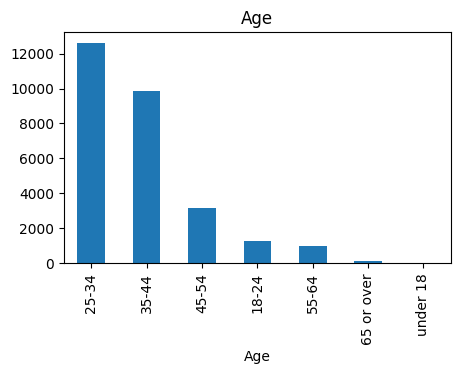

Age


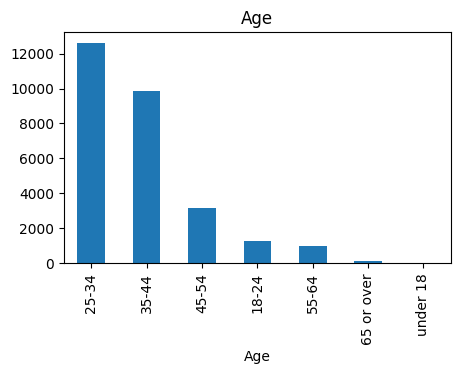

Overall years of experience


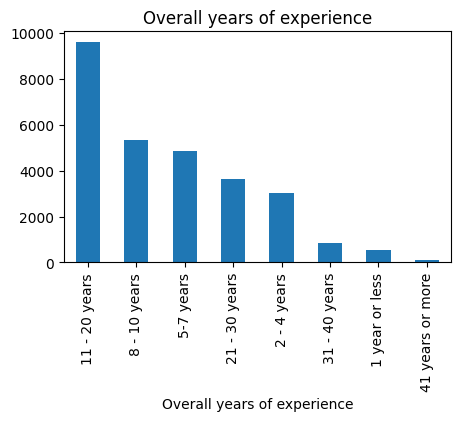

Years of experience in current job


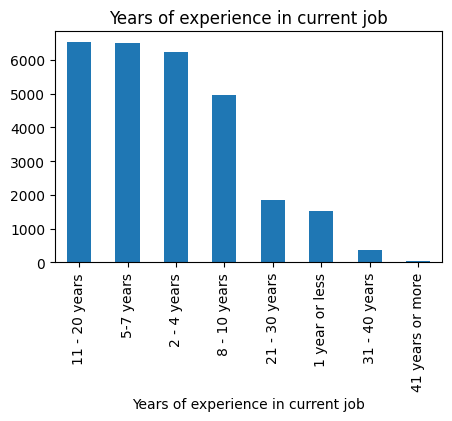

Education level


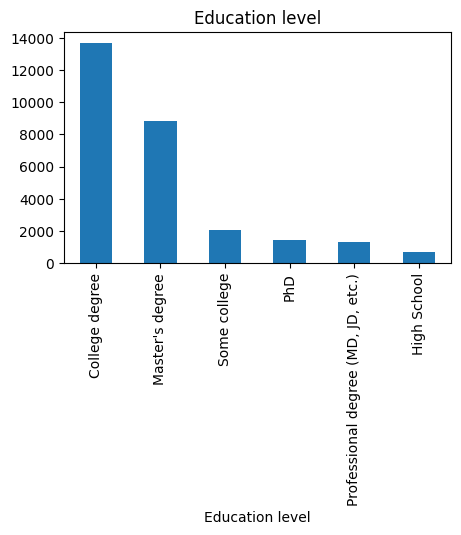

Gender


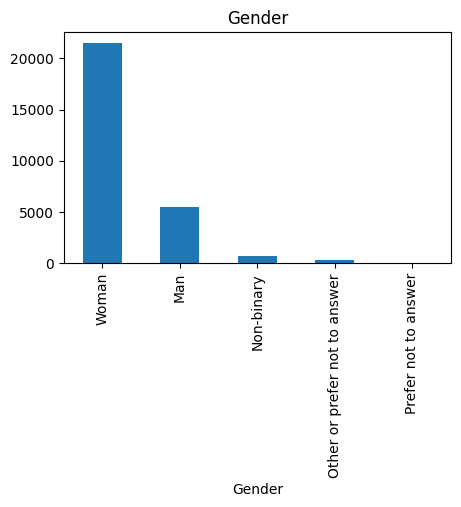

In [21]:
import matplotlib.pyplot as plt

for item in feature_small:
  column_name = item[0]
  print(column_name)

  df_master[column_name].value_counts().plot(kind = 'bar',figsize=(5,3),title=column_name)
  plt.show()

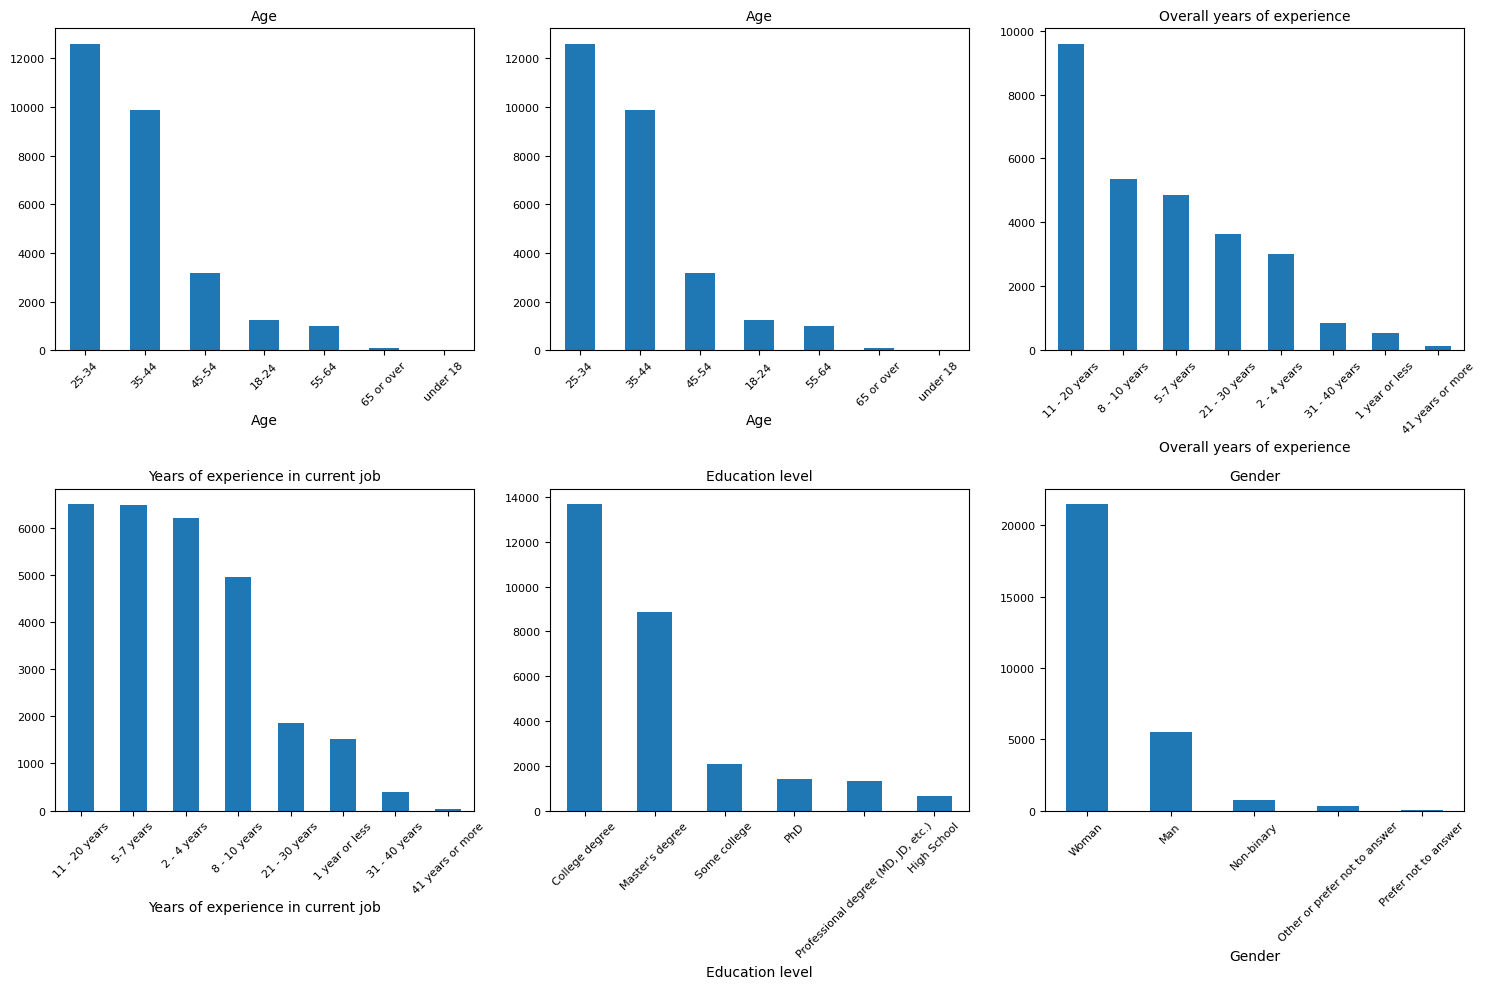

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for k, item in enumerate(feature_small[:6]):
  column_name = item[0]
  df_master[column_name].value_counts().plot(
      kind='bar', ax=axes[k], fontsize=8, rot=45
  )
  axes[k].set_title(column_name, fontsize=10)

plt.tight_layout()
plt.show()

<Axes: >

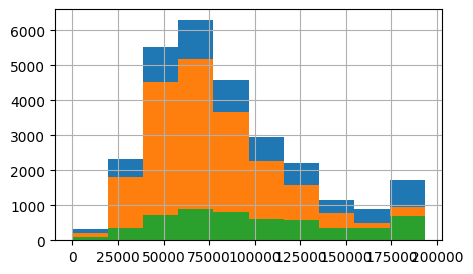

In [23]:
df_master['Salary'].hist(figsize=(5,3))
df_master[df_master['Gender']=='Woman']['Salary'].hist(figsize=(5,3))  # subset by gender
df_master[df_master['Gender']=='Man']['Salary'].hist(figsize=(5,3))

# -------------------------------------
# df_master['Salary'].hist(figsize=(5,3))
# plt.title("Salary Distribution (All)")
# plt.show()

# df_master[df_master['Gender']=='Woman']['Salary'].hist(figsize=(5,3))
# plt.title("Salary Distribution (Women)")
# plt.show()

# df_master[df_master['Gender']=='Man']['Salary'].hist(figsize=(5,3))
# plt.title("Salary Distribution (Men)")
# plt.show()

# ------------Box Plot (Salary Vs Gender) -------------------------

# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.boxplot(x='Gender', y='Salary', data=df_master)
# plt.title('Salary Distribution by Gender (Boxplot)')
# plt.show()

In [24]:
numerical_cols = df_master.select_dtypes(include=np.number).columns.tolist()

df_woman = df_master[df_master['Gender']=='Woman']
df_man = df_master[df_master['Gender']=='Man']

print("Numeric columns:", numerical_cols)

print("\nCorrelation (Women):")
display(df_woman[numerical_cols].corr())

print("\nCorrelation (Men):")
display(df_man[numerical_cols].corr())

Numeric columns: ['Salary', 'Compensation', 'Salary_USD', 'Compensation_USD', 'CGPA', 'Salary_month_USD', 'Special Bonus_GBP']

Correlation (Women):


,Salary,Compensation,Salary_USD,Compensation_USD,CGPA,Salary_month_USD,Special Bonus_GBP
Salary,1.000000,0.446363,0.954137,0.432546,0.004049,-0.009609,0.005901
Compensation,0.446363,1.000000,0.453474,0.992226,-0.005529,-0.013478,-0.005587
Salary_USD,0.954137,0.453474,1.000000,0.462607,0.000726,-0.009809,0.004753
Compensation_USD,0.432546,0.992226,0.462607,1.000000,-0.005687,-0.012716,-0.004463
CGPA,0.004049,-0.005529,0.000726,-0.005687,1.000000,0.002508,0.003476
Salary_month_USD,-0.009609,-0.013478,-0.009809,-0.012716,0.002508,1.000000,0.000857
Special Bonus_GBP,0.005901,-0.005587,0.004753,-0.004463,0.003476,0.000857,1.000000



Correlation (Men):


,Salary,Compensation,Salary_USD,Compensation_USD,CGPA,Salary_month_USD,Special Bonus_GBP
Salary,1.000000,0.470134,0.958438,0.450614,0.005384,0.013269,0.020659
Compensation,0.470134,1.000000,0.464778,0.986752,-0.018615,0.042800,0.004426
Salary_USD,0.958438,0.464778,1.000000,0.478285,0.008259,0.014590,0.019341
Compensation_USD,0.450614,0.986752,0.478285,1.000000,-0.018372,0.040179,0.003209
CGPA,0.005384,-0.018615,0.008259,-0.018372,1.000000,0.018007,0.009082
Salary_month_USD,0.013269,0.042800,0.014590,0.040179,0.018007,1.000000,0.012899
Special Bonus_GBP,0.020659,0.004426,0.019341,0.003209,0.009082,0.012899,1.000000


,Education_level,mean_woman,mean_man
0,Master's degree,83955.901357,103578.677603
1,College degree,77980.514118,100759.902722
2,PhD,96097.628391,119593.238095
3,Some college,64659.141489,91124.391597
4,High School,58720.541667,88295.623016
5,"Professional degree (MD, JD, etc.)",119303.720146,126788.188482


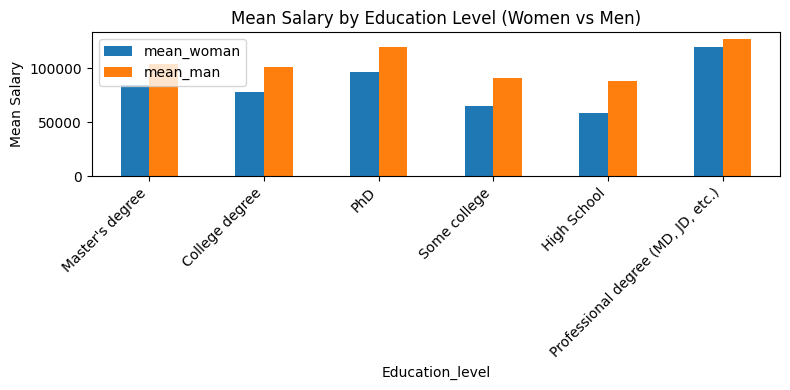

In [25]:
edu_col = 'Education level'  # keeping your column naming

edu_levels = df_master[edu_col].dropna().unique()

records = []
for level in edu_levels:
  mean_w = df_woman[df_woman[edu_col] == level]['Salary'].mean()
  mean_m = df_man[df_man[edu_col] == level]['Salary'].mean()
  records.append([level, mean_w, mean_m])

salary_by_edu = pd.DataFrame(records, columns=['Education_level', 'mean_woman', 'mean_man'])
display(salary_by_edu)

salary_by_edu.set_index('Education_level')[['mean_woman','mean_man']].plot.bar(figsize=(8,4))
plt.title("Mean Salary by Education Level (Women vs Men)")
plt.ylabel("Mean Salary")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [26]:
group_cols = []
for col in ['Education level', 'Age', 'Overall years of experience']:
  if col in df_master.columns:
    group_cols.append(col)

if len(group_cols) == 0:
  print("None of ['Education level', 'Age', 'Overall years of experience'] were found.")
else:
  display(df_master.groupby(group_cols)['Salary'].mean().reset_index().head(10))

,Education level,Age,Overall years of experience,Salary
0,College degree,18-24,1 year or less,56847.684000
1,College degree,18-24,11 - 20 years,85850.000000
2,College degree,18-24,2 - 4 years,61349.634483
3,College degree,18-24,21 - 30 years,65000.000000
4,College degree,18-24,5-7 years,48582.708861
5,College degree,18-24,8 - 10 years,41482.333333
6,College degree,25-34,1 year or less,54013.442308
7,College degree,25-34,11 - 20 years,86591.564717
8,College degree,25-34,2 - 4 years,66150.943163
9,College degree,25-34,21 - 30 years,21149.666667


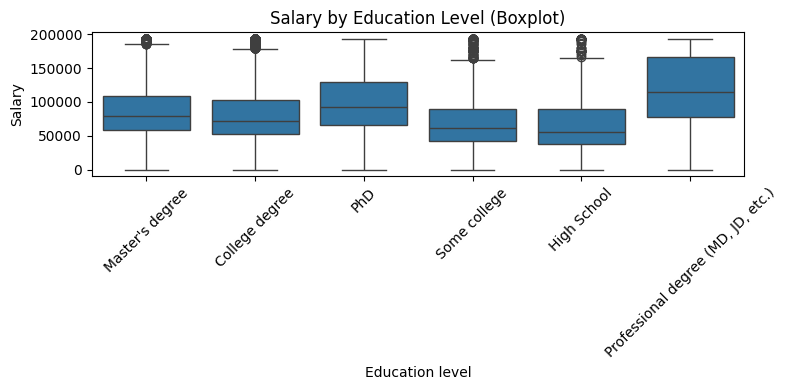

In [27]:
import seaborn as sns

if 'Education level' in df_master.columns:
  plt.figure(figsize=(8,4))
  sns.boxplot(x='Education level', y='Salary', data=df_master)
  plt.title('Salary by Education Level (Boxplot)')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()
else:
  print("Education level column not found.")

In [30]:
def analysis_by_category(category):
  levels = df_master[category].dropna().unique()

  rows = []
  for level in levels:
    mean_w = df_woman[df_woman[category] == level]['Salary'].mean()
    mean_m = df_man[df_man[category] == level]['Salary'].mean()
    rows.append([level, mean_w, mean_m])

  salary_by_cat = pd.DataFrame(rows, columns=[category, 'mean_woman', 'mean_man'])
  display(salary_by_cat)

  salary_by_cat.set_index(category)[['mean_woman','mean_man']].plot.bar(figsize=(9,4))
  plt.title(f"Mean Salary by {category} (Women vs Men)")
  plt.ylabel("Mean Salary")
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

,Age,mean_woman,mean_man
0,25-34,76484.807342,91405.772849
1,45-54,90133.384174,120800.433036
2,35-44,88569.775864,111609.655370
3,18-24,56717.810443,55119.111913
4,65 or over,91719.726027,95966.800000
5,55-64,86332.071960,117063.005882
6,under 18,50392.100000,20000.500000


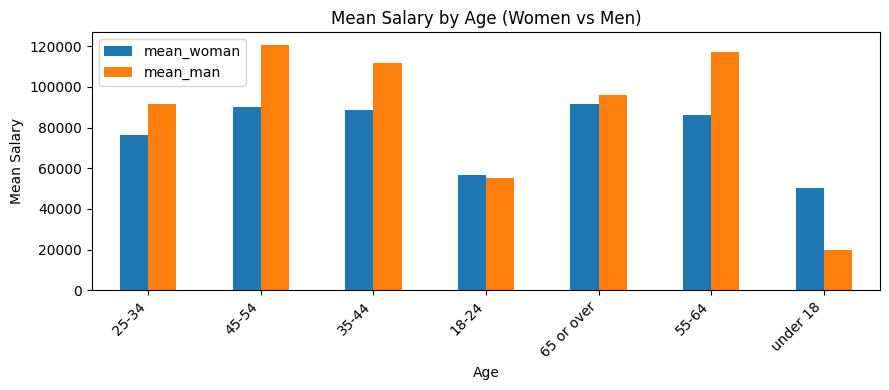

In [31]:
category = "Age"
analysis_by_category(category)

,Overall years of experience,mean_woman,mean_man
0,5-7 years,73988.912557,87062.489510
1,8 - 10 years,81266.231312,98631.900780
2,2 - 4 years,65003.413063,72037.775475
3,21 - 30 years,91557.732892,121893.629854
4,11 - 20 years,88156.254993,110689.870474
5,1 year or less,60761.068241,59093.574803
6,41 years or more,84667.939024,108321.589744
7,31 - 40 years,89499.108108,120387.595628


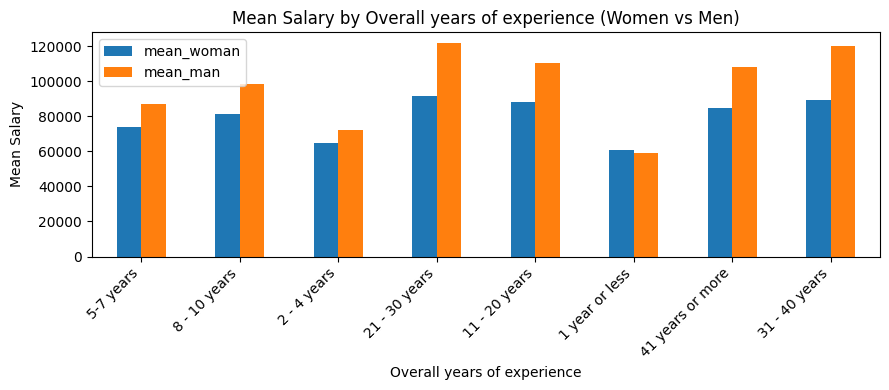

In [32]:
if 'Overall years of experience' in df_master.columns:
  analysis_by_category('Overall years of experience')
else:
  print("'Overall years of experience' column not found.")

,Age,mean_woman,mean_man
0,25-34,76484.807342,91405.772849
1,45-54,90133.384174,120800.433036
2,35-44,88569.775864,111609.655370
3,18-24,56717.810443,55119.111913
4,65 or over,91719.726027,95966.800000
5,55-64,86332.071960,117063.005882
6,under 18,50392.100000,20000.500000


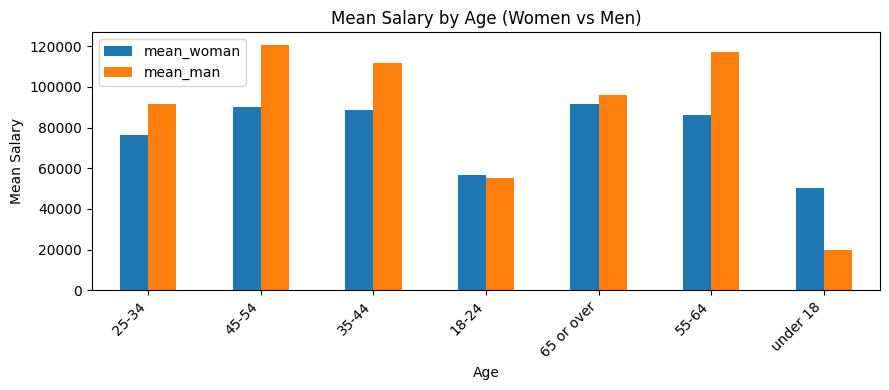

In [33]:
if 'Age' in df_master.columns:
  analysis_by_category('Age')
else:
  print("'Age' column not found.")

In [36]:
x = df_master[(df_master['Gender']=="Woman") & (df_master['Age']=="under 18")]
x[x['Salary'] > 60000]


,Age,Industry,Job title,Salary,Compensation,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race,Salary_USD,Compensation_USD,CGPA,Salary_month_USD,Special Bonus_GBP
10719,under 18,Nonprofits,Finance Director,118000.0,0.0,United States,District of Columbia,Washington,31 - 40 years,11 - 20 years,Master's degree,Woman,White,118000.0,0.0,3.063527,8291.666667,1099.0
25053,under 18,Law,Records manager,106000.0,3200.0,USA,Colorado,Denver,41 years or more,1 year or less,Master's degree,Woman,White,106000.0,3200.0,NaN,NaN,NaN
25601,under 18,Retail,Technology Manager,100200.0,12000.0,USA,Virginia,Richmond,21 - 30 years,21 - 30 years,Some college,Woman,"Hispanic, Latino, or Spanish origin",100200.0,12000.0,NaN,NaN,NaN


In [37]:
df_master['Job title'].value_counts()

,count
Job title,
Software Engineer,287
Project Manager,227
Director,198
Senior Software Engineer,194
Program Manager,153
...,...
Director of Agency Services,1
Teacher - high school,1
Payroll Administration,1


,0
Software Engineer,287
Project Manager,227
Director,198
Senior Software Engineer,194
Program Manager,153
Librarian,150
Teacher,149
Manager,144
Executive Assistant,134
Product Manager,124


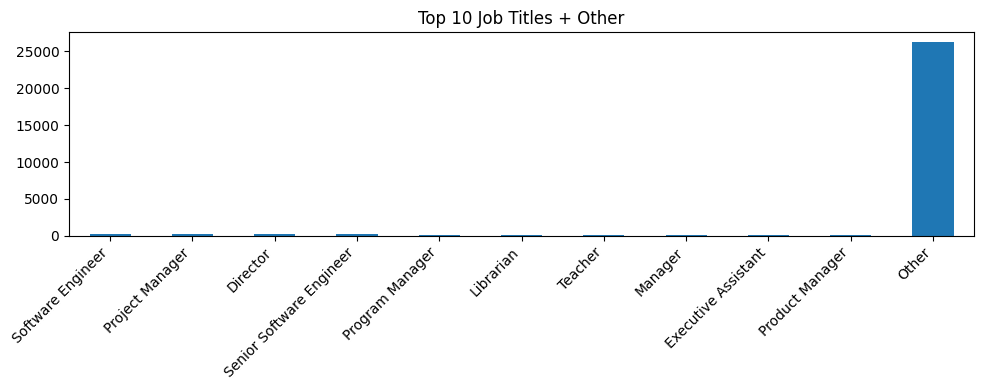

In [38]:
if 'Job title' in df_master.columns:
  top_n = 10
  job_counts = df_master['Job title'].value_counts()

  top = job_counts.head(top_n)
  other = pd.Series({'Other': job_counts.iloc[top_n:].sum()})
  top_plus_other = pd.concat([top, other])

  display(top_plus_other)

  top_plus_other.plot(kind='bar', figsize=(10,4), title=f'Top {top_n} Job Titles + Other')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()
else:
  print("'Job title' column not found.")
